O dataset possui 1460 linhas e 81 colunas.



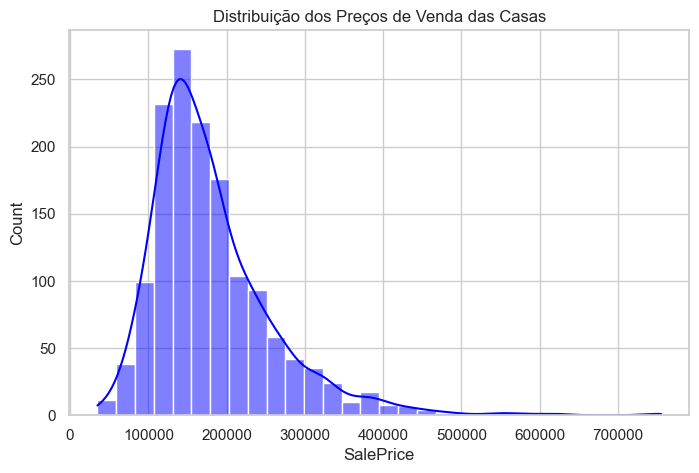


Top 5 colunas com valores faltantes:


PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
dtype: int64


Variáveis Numéricas (38): ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual']...
Variáveis Categóricas (43): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour']...


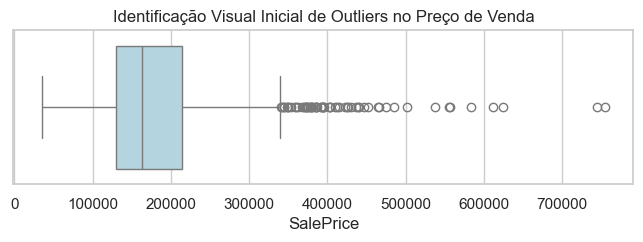

Parte 1 concluida


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

caminho_arquivo = r"C:\Users\guilh\OneDrive\Pictures\train.csv"
df_train = pd.read_csv(caminho_arquivo)

print(f"O dataset possui {df_train.shape[0]} linhas e {df_train.shape[1]} colunas.\n")

plt.figure(figsize=(8, 5))
sns.histplot(df_train['SalePrice'], kde=True, bins=30, color='blue')
plt.title('Distribuição dos Preços de Venda das Casas')
plt.show()

print("\nTop 5 colunas com valores faltantes:")
display(df_train.isnull().sum().sort_values(ascending=False).head(5))

num_cols_eda = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_eda = df_train.select_dtypes(include=['object']).columns.tolist()
print(f"\nVariáveis Numéricas ({len(num_cols_eda)}): {num_cols_eda[:5]}...")
print(f"Variáveis Categóricas ({len(cat_cols_eda)}): {cat_cols_eda[:5]}...")

plt.figure(figsize=(8, 2))
sns.boxplot(x=df_train['SalePrice'], color='lightblue')
plt.title('Identificação Visual Inicial de Outliers no Preço de Venda')
plt.show()

print("Parte 1 concluida")

In [4]:
num_cols = df_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_train.select_dtypes(include=['object']).columns

for col in num_cols:
    df_train[col] = df_train[col].fillna(df_train[col].median())
for col in cat_cols:
    df_train[col] = df_train[col].fillna('None')

df_train['AreaTotalCasa'] = df_train['TotalBsmtSF'] + df_train['1stFlrSF'] + df_train['2ndFlrSF']

df_encoded = pd.get_dummies(df_train)

correlacoes = df_encoded.corr()['SalePrice'].sort_values(ascending=False)
features_importantes = correlacoes[abs(correlacoes) > 0.5].index.tolist()

if 'SalePrice' in features_importantes:
    features_importantes.remove('SalePrice')

X = df_encoded[features_importantes]
y = df_encoded['SalePrice']

#  ao : Normalização
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Feature Engineering concluído! Dados normalizados e selecionados com sucesso.")
display(X_scaled.head())
print("Parte 2 concluida")

Feature Engineering concluído! Dados normalizados e selecionados com sucesso.


,OverallQual,AreaTotalCasa,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,BsmtQual_Ex,TotRmsAbvGrd,YearBuilt,YearRemodAdd,KitchenQual_Ex,KitchenQual_TA,ExterQual_TA
0,0.651479,-0.001277,0.370333,0.311725,0.351000,-0.459303,-0.793434,0.789741,-0.300609,0.912210,1.050994,0.878668,-0.271163,-1.006873,-1.278819
1,-0.071836,-0.052407,-0.482512,0.311725,-0.060731,0.466465,0.257140,0.789741,-0.300609,-0.318683,0.156734,-0.429577,-0.271163,0.993174,0.781971
2,0.651479,0.169157,0.515013,0.311725,0.631726,-0.313369,-0.627826,0.789741,-0.300609,-0.318683,0.984752,0.830215,-0.271163,-1.006873,-1.278819
3,0.651479,-0.114493,0.383659,1.650307,0.790804,-0.687324,-0.521734,-1.026041,-0.300609,0.296763,-1.863632,-0.720298,-0.271163,-1.006873,0.781971
4,1.374795,0.944631,1.299326,1.650307,1.698485,0.199680,-0.045611,0.789741,-0.300609,1.527656,0.951632,0.733308,-0.271163,-1.006873,-1.278819


Parte 2 concluida


============ ITEM 3.a: REGRESSÃO LINEAR MÚLTIPLA ============
R² (Coeficiente de Determinação): 0.8303 (O modelo explica 83.03% da variação dos preços)
MAE (Erro Médio Absoluto): $22636.15 (Em média, o modelo erra por esse valor)
MSE (Erro Quadrático Médio): 1302035616.79
RMSE (Raiz do Erro Quadrático Médio): $36083.73



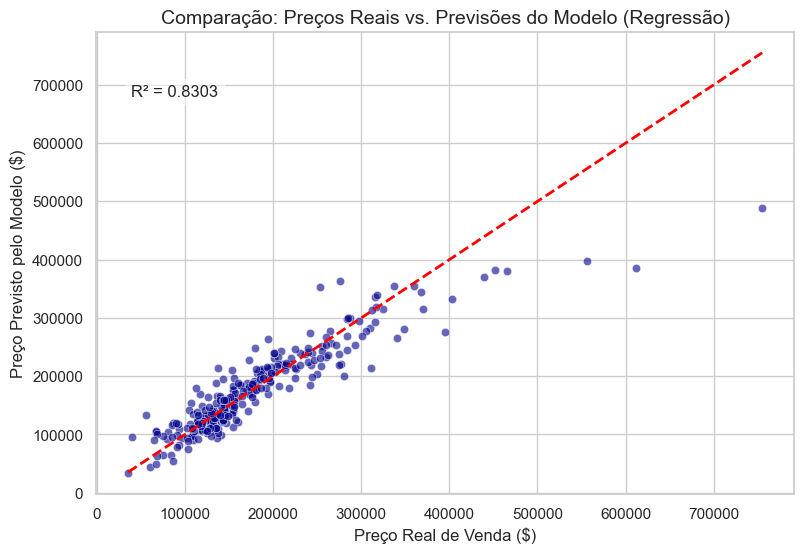

Parte 3 concluida


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

modelo_reg = LinearRegression()
modelo_reg.fit(X_train_reg, y_train_reg)

y_pred_reg = modelo_reg.predict(X_test_reg)

r2 = r2_score(y_test_reg, y_pred_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)

print("============ ITEM 3.a: REGRESSÃO LINEAR MÚLTIPLA ============")
print(f"R² (Coeficiente de Determinação): {r2:.4f} (O modelo explica {r2*100:.2f}% da variação dos preços)")
print(f"MAE (Erro Médio Absoluto): ${mae:.2f} (Em média, o modelo erra por esse valor)")
print(f"MSE (Erro Quadrático Médio): {mse:.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): ${rmse:.2f}")
print("=============================================================\n")

plt.figure(figsize=(9, 6))
sns.scatterplot(x=y_test_reg, y=y_pred_reg, alpha=0.6, color='darkblue')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], color='red', lw=2, linestyle='--')
plt.title('Comparação: Preços Reais vs. Previsões do Modelo (Regressão)', fontsize=14)
plt.xlabel('Preço Real de Venda ($)', fontsize=12)
plt.ylabel('Preço Previsto pelo Modelo ($)', fontsize=12)
plt.text(y_test_reg.min()*1.1, y_test_reg.max()*0.9, f'R² = {r2:.4f}', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
plt.show()
print("Parte 3 concluida")

In [6]:
!pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\guilh\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


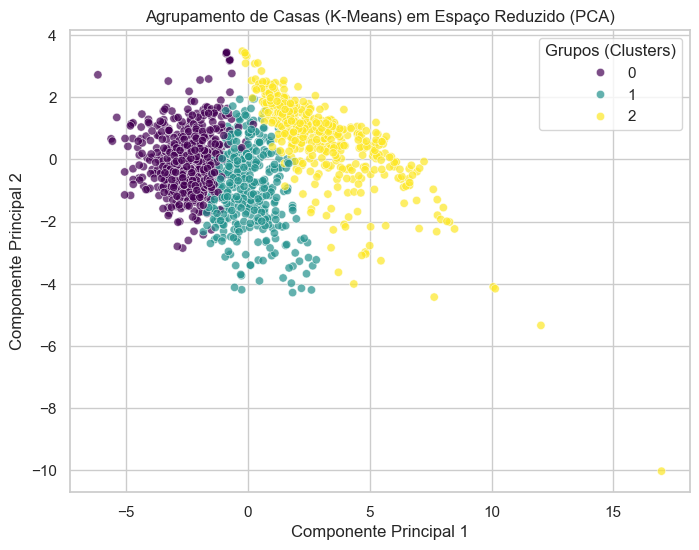

In [7]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis', alpha=0.7)
plt.title('Agrupamento de Casas (K-Means) em Espaço Reduzido (PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Grupos (Clusters)')
plt.show()

In [8]:
from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd

df_apriori = pd.DataFrame()
df_apriori['Qualidade_Alta'] = df_train['OverallQual'] >= 7
df_apriori['Casa_Moderna'] = df_train['YearBuilt'] >= 2000
df_apriori['Tem_Garagem'] = df_train['GarageArea'] > 0
df_apriori['Tem_Ar_Central'] = df_train['CentralAir'] == 'Y'

frequent_itemsets = apriori(df_apriori, min_support=0.2, use_colnames=True)

regras = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

print("--- Principais Regras de Associação Encontradas ---")
display(regras[['antecedents', 'consequents', 'support', 'confidence']].sort_values(by='confidence', ascending=False).head(10))

--- Principais Regras de Associação Encontradas ---


,antecedents,consequents,support,confidence
4,(Casa_Moderna),(Tem_Ar_Central),0.265753,1.000000
11,"(Casa_Moderna, Qualidade_Alta)",(Tem_Ar_Central),0.223288,1.000000
16,"(Tem_Garagem, Casa_Moderna)",(Tem_Ar_Central),0.263699,1.000000
20,"(Tem_Garagem, Casa_Moderna, Qualidade_Alta)",(Tem_Ar_Central),0.222603,1.000000
14,"(Tem_Ar_Central, Qualidade_Alta)",(Tem_Garagem),0.370548,0.998155
21,"(Tem_Ar_Central, Casa_Moderna, Qualidade_Alta)",(Tem_Garagem),0.222603,0.996933
24,"(Casa_Moderna, Qualidade_Alta)","(Tem_Garagem, Tem_Ar_Central)",0.222603,0.996933
8,"(Casa_Moderna, Qualidade_Alta)",(Tem_Garagem),0.222603,0.996933
1,(Qualidade_Alta),(Tem_Garagem),0.373973,0.996350
3,(Casa_Moderna),(Tem_Garagem),0.263699,0.992268


--- Resultados do Local Outlier Factor (LOF) ---
Casas dentro do padrão (Inliers): 1387
Casas anômalas (Outliers): 73


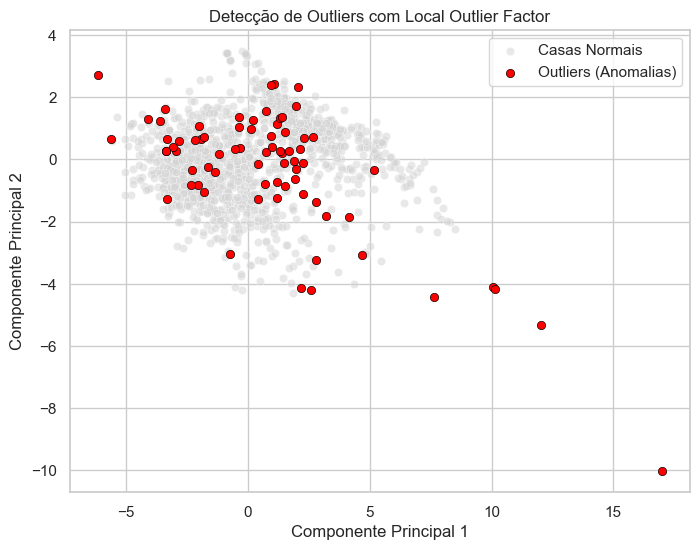

Parte 4 concluida


In [9]:
from sklearn.neighbors import LocalOutlierFactor


lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
outliers_pred = lof.fit_predict(X_scaled)

is_outlier = outliers_pred == -1

print("--- Resultados do Local Outlier Factor (LOF) ---")
print(f"Casas dentro do padrão (Inliers): {sum(~is_outlier)}")
print(f"Casas anômalas (Outliers): {sum(is_outlier)}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], color='lightgrey', label='Casas Normais', alpha=0.5)
sns.scatterplot(x=X_pca[is_outlier, 0], y=X_pca[is_outlier, 1], color='red', label='Outliers (Anomalias)', edgecolor='black')
plt.title('Detecção de Outliers com Local Outlier Factor')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.show()
print("Parte 4 concluida")

============ 5. MÉTRICAS E COMPARAÇÃO DE MODELOS ============

--- A. Desempenho dos Modelos Supervisionados ---


,Modelo,R² (Poder de Explicação),MAE (Erro Médio),RMSE (Raiz do Erro Quadrático)
0,Regressão Linear,0.8303,$22636.15,$36083.73


,Modelo,Acurácia,Precisão,Recall,F1-Score
0,Regressão Logística (Classificação),0.9418,0.9191,0.9542,0.9363



--- B. Comparação: Modelos Supervisionados vs. Não Supervisionado (K-Means) ---


,Cluster (K-Means),Qtd de Casas,Preço Médio Real ($),% de Casas com Preço Alto
0,0,587,123415.55,4.77
1,1,378,173720.94,59.52
2,2,495,254613.13,95.96


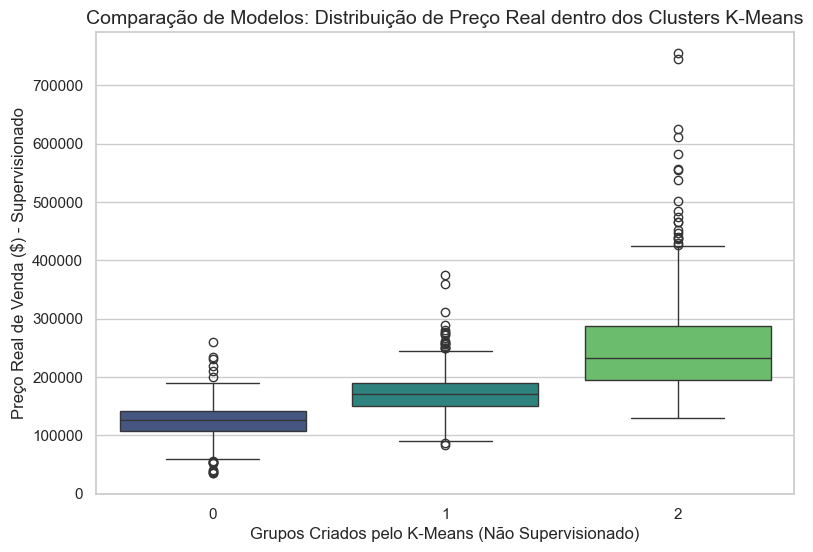

Parte 5 concluida


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score

print("============ 5. MÉTRICAS E COMPARAÇÃO DE MODELOS ============\n")


X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
modelo_reg = LinearRegression().fit(X_train_reg, y_train_reg)
y_pred_reg = modelo_reg.predict(X_test_reg)
r2 = r2_score(y_test_reg, y_pred_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))

y_binario = np.where(y > y.median(), 1, 0)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_scaled, y_binario, test_size=0.2, random_state=42)
modelo_clf = LogisticRegression().fit(X_train_clf, y_train_clf)
y_pred_clf = modelo_clf.predict(X_test_clf)
acuracia = accuracy_score(y_test_clf, y_pred_clf)
precisao = precision_score(y_test_clf, y_pred_clf)
recall = recall_score(y_test_clf, y_pred_clf)
f1 = f1_score(y_test_clf, y_pred_clf)

print("--- A. Desempenho dos Modelos Supervisionados ---")
df_metricas_reg = pd.DataFrame({
    'Modelo': ['Regressão Linear'],
    'R² (Poder de Explicação)': [f"{r2:.4f}"],
    'MAE (Erro Médio)': [f"${mae:.2f}"],
    'RMSE (Raiz do Erro Quadrático)': [f"${rmse:.2f}"]
})
display(df_metricas_reg)

df_metricas_clf = pd.DataFrame({
    'Modelo': ['Regressão Logística (Classificação)'],
    'Acurácia': [f"{acuracia:.4f}"],
    'Precisão': [f"{precisao:.4f}"],
    'Recall': [f"{recall:.4f}"],
    'F1-Score': [f"{f1:.4f}"]
})
display(df_metricas_clf)

print("\n--- B. Comparação: Modelos Supervisionados vs. Não Supervisionado (K-Means) ---")

df_comparacao = pd.DataFrame({
    'Cluster_KMeans': clusters,
    'Preco_Real': y,
    'Preco_Binario_Supervisionado': y_binario
})

resumo_clusters = df_comparacao.groupby('Cluster_KMeans').agg(
    Qtd_Casas=('Preco_Real', 'count'),
    Preco_Medio_Real=('Preco_Real', 'mean'),
    Taxa_Preco_Alto_Percentual=('Preco_Binario_Supervisionado', lambda x: x.mean() * 100)
).reset_index()

resumo_clusters.columns = ['Cluster (K-Means)', 'Qtd de Casas', 'Preço Médio Real ($)', '% de Casas com Preço Alto']
display(resumo_clusters.round(2))

plt.figure(figsize=(9, 6))
sns.boxplot(x='Cluster_KMeans', y='Preco_Real', data=df_comparacao, palette='viridis')
plt.title('Comparação de Modelos: Distribuição de Preço Real dentro dos Clusters K-Means', fontsize=14)
plt.xlabel('Grupos Criados pelo K-Means (Não Supervisionado)', fontsize=12)
plt.ylabel('Preço Real de Venda ($) - Supervisionado', fontsize=12)
plt.show()
print("Parte 5 concluida")